# Finite element method demos
First: 1-D diffusion, constant coefficient, Dirichlet BCs

In [1]:
using LinearAlgebra
using Plots

In [23]:
# FEM solver for d²T/dx² + f = 0 where f = 50 exp(x)
#
# Boundary conditions
#   T(-1) = 100 and T(1) = 100

nElem = 5
x = collect(range(-1.0, 1.0, length=nElem + 1))

K = zeros(nElem + 1, nElem + 1);
F = zeros(nElem + 1);

In [24]:
for elem in 1:nElem
    n1 = elem
    n2 = elem + 1

    x1 = x[n1]
    x2 = x[n2]
    dx = x2 - x1

    # Stiffness contributions
    K[n1, n1] -= 1 / dx
    K[n1, n2] += 1 / dx
    K[n2, n1] += 1 / dx
    K[n2, n2] -= 1 / dx

    # Forcing contributions
    F[n1] -= 50 * (exp(x2) - x2 * exp(x1) + x1 * exp(x1) - exp(x1)) / dx
    F[n2] -= 50 * (x2 * exp(x2) - exp(x2) - x1 * exp(x2) + exp(x1)) / dx
end

In [25]:
# Left boundary: x = -1
n1 = 1
K[n1, :] .= 0.0
K[n1, n1] = 1.0
F[n1] = 100.0;

# Right boundary: x = 1
n1 = nElem + 1
K[n1, :] .= 0.0
K[n1, n1] = 1.0
F[n1] = 100.0;

In [26]:
# solve
T = K \ F;

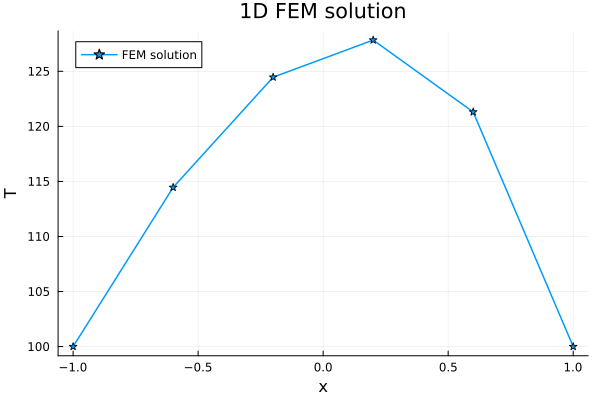

In [27]:
plot(x, T,
    marker = :star,
    linewidth = 1.5,
    xlabel = "x",
    ylabel = "T",
    label = "FEM solution",
    title = "1D FEM solution")

In [28]:
# For the exact solution, use a finer grid for smooth plotting.
Npt = 20 * nElem + 1
xe = collect(range(-1.0, 1.0, length=Npt))

Te = -50 .* exp.(xe) .+ 50 .* xe .* sinh(1) .+ 100 .+ 50 .* cosh(1);

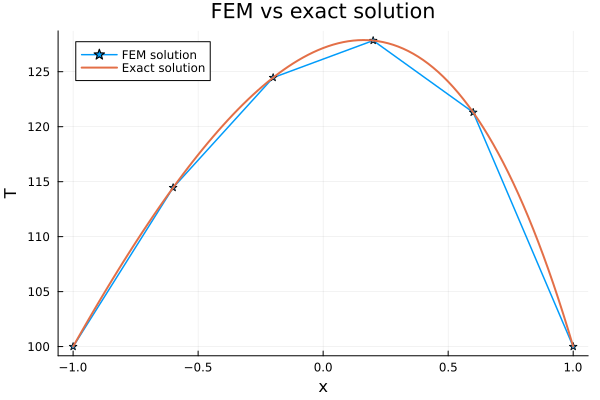

In [29]:
plot(x, T,
    marker = :star,
    linewidth = 1.5,
    label = "FEM solution",
    xlabel = "x",
    ylabel = "T",
    title = "FEM vs exact solution")

plot!(xe, Te, linewidth = 2, label = "Exact solution")

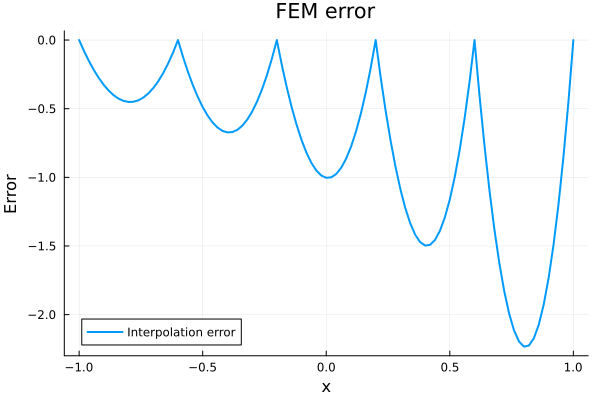

In [30]:
# compare exact and approximate solutions

Terr = zeros(Npt)
Terr[1] = T[1] - Te[1]

h = x[2] - x[1]

for i in 2:(Npt - 1)
    xxi = xe[i]
    Tei = Te[i]

    j = floor(Int, (xxi - xe[1]) / h) + 1
    j = min(j, nElem)  # protect against roundoff near the right boundary

    x0 = x[j]
    x1 = x[j + 1]
    T0 = T[j]
    T1 = T[j + 1]

    ξ = 2 * (xxi - x0) / (x1 - x0) - 1
    Ti = 0.5 * (1 - ξ) * T0 + 0.5 * (1 + ξ) * T1

    Terr[i] = Ti - Tei
end

Terr[end] = T[end] - Te[end]

plot(xe, Terr,
    linewidth = 2,
    xlabel = "x",
    ylabel = "Error",
    label = "Interpolation error",
    title = "FEM error",
    grid = true)